In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv(r'../pre-calculated_data/sample_bins_info_mimag_gc.tsv',sep='\t')
df = df[['Sample','Mag ID','Completeness','Contamination','MIMAG','Drep_95','Nr contigs','Quality','N50','L50','GC content']]
df.loc[df['MIMAG'] == 'T', 'Quality'] = 'HQ-MIMAG'
df

,Sample,Mag ID,Completeness,Contamination,MIMAG,Drep_95,Nr contigs,Quality,N50,L50,GC content
0,cpsnj01,cpsnj01_SemiBin_0,99.97,0.22,T,T,10,HQ-MIMAG,748488,3,0.467241
1,cpsnj01,cpsnj01_SemiBin_10,91.13,2.78,T,T,14,HQ-MIMAG,733099,3,0.657316
2,cpsnj01,cpsnj01_SemiBin_110,50.92,1.11,F,T,30,Medium quality,172645,9,0.662246
3,cpsnj01,cpsnj01_SemiBin_112,57.39,6.50,F,T,55,Medium quality,117499,16,0.657481
4,cpsnj01,cpsnj01_SemiBin_115,57.02,0.00,F,F,35,Medium quality,144473,10,0.461886
...,...,...,...,...,...,...,...,...,...,...,...
7944,snj20,snj20_SemiBin_95,70.43,9.78,F,T,17,Medium quality,227894,4,0.638630
7945,snj20,snj20_SemiBin_963,65.69,9.61,F,T,25,Medium quality,212925,8,0.657995
7946,snj20,snj20_SemiBin_96,59.11,5.13,F,F,32,Medium quality,195695,7,0.688068
7947,snj20,snj20_SemiBin_97,53.23,4.62,F,T,17,Medium quality,108637,4,0.674686


In [4]:
quality_counts = df.groupby(['Sample', 'Quality']).size().unstack(fill_value=0)
quality_counts['all'] = quality_counts['HQ-MIMAG']+quality_counts['High quality']+quality_counts['Medium quality']
quality_counts = quality_counts.sort_values(by='all', ascending=False)
quality_counts = quality_counts.drop('all',axis=1)

([], [])

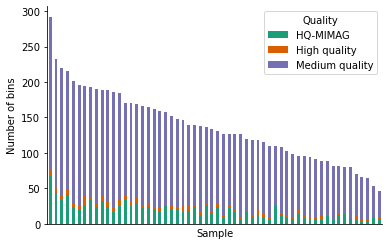

In [5]:
ax =quality_counts.plot.bar(stacked=True,color=['#1b9e77','#d95f02','#7570b3'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set(ylabel="Number of bins")
plt.xticks([])

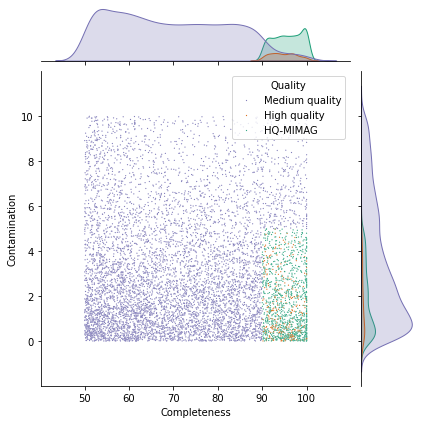

In [6]:
custom_palette = {
    'Medium quality': '#7570b3',
    'High quality': '#d95f02',
    'HQ-MIMAG': '#1b9e77'
}
sns.jointplot(data=df, x="Completeness", y="Contamination",hue="Quality",s=1.5,hue_order=['Medium quality','High quality','HQ-MIMAG'],palette=custom_palette)

In [7]:
df['log(N50)'] = np.log(df['N50'])
df

,Sample,Mag ID,Completeness,Contamination,MIMAG,Drep_95,Nr contigs,Quality,N50,L50,GC content,log(N50)
0,cpsnj01,cpsnj01_SemiBin_0,99.97,0.22,T,T,10,HQ-MIMAG,748488,3,0.467241,13.525810
1,cpsnj01,cpsnj01_SemiBin_10,91.13,2.78,T,T,14,HQ-MIMAG,733099,3,0.657316,13.505036
2,cpsnj01,cpsnj01_SemiBin_110,50.92,1.11,F,T,30,Medium quality,172645,9,0.662246,12.058993
3,cpsnj01,cpsnj01_SemiBin_112,57.39,6.50,F,T,55,Medium quality,117499,16,0.657481,11.674185
4,cpsnj01,cpsnj01_SemiBin_115,57.02,0.00,F,F,35,Medium quality,144473,10,0.461886,11.880848
...,...,...,...,...,...,...,...,...,...,...,...,...
7944,snj20,snj20_SemiBin_95,70.43,9.78,F,T,17,Medium quality,227894,4,0.638630,12.336636
7945,snj20,snj20_SemiBin_963,65.69,9.61,F,T,25,Medium quality,212925,8,0.657995,12.268695
7946,snj20,snj20_SemiBin_96,59.11,5.13,F,F,32,Medium quality,195695,7,0.688068,12.184313
7947,snj20,snj20_SemiBin_97,53.23,4.62,F,T,17,Medium quality,108637,4,0.674686,11.595767


<ipython-input-8-0e7bf7d88696>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=df, x="Quality", y='log(N50)',color='white',
<ipython-input-8-0e7bf7d88696>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Quality", y='log(N50)',size=2,order=['Medium quality','High quality','HQ-MIMAG'],palette=custom_palette)


Text(0.5, 0, '')

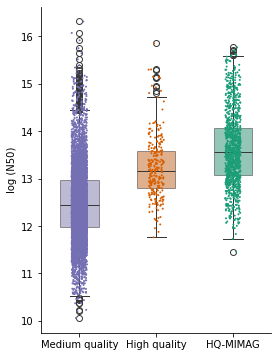

In [8]:
fig, ax = plt.subplots(figsize=(4, 6))
custom_palette = {
    'Medium quality': '#7570b3',
    'High quality': '#d95f02',
    'HQ-MIMAG': '#1b9e77'
}
ax=sns.boxplot(data=df, x="Quality", y='log(N50)',color='white',
               width=.5,order=['Medium quality','High quality','HQ-MIMAG'],palette=custom_palette,boxprops=dict(alpha=0.5) )
sns.stripplot(data=df, x="Quality", y='log(N50)',size=2,order=['Medium quality','High quality','HQ-MIMAG'],palette=custom_palette)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.subplots_adjust(left=0.2, right=1) 
ax.set_ylabel('log (N50)')
ax.set_xlabel('')

In [2]:
df = pd.read_csv(r'../pre-calculated_data/mapping.csv')
df

,mapping rate,target,type
0,72.25,contigs,sr
1,60.20,contigs,sr
2,65.74,contigs,sr
3,65.99,contigs,sr
4,59.71,contigs,sr
...,...,...,...
227,73.67,MAGs,lr
228,67.36,MAGs,lr
229,68.54,MAGs,lr
230,79.03,MAGs,lr


<ipython-input-4-8537de4047aa>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=df_lr, width=.5,x="target", y="mapping rate",color='white',order=target_order,palette=custom_palette,boxprops=dict(alpha=0.6) )
<ipython-input-4-8537de4047aa>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df_lr, x="target",s=4,y="mapping rate",order=target_order,palette=custom_palette)


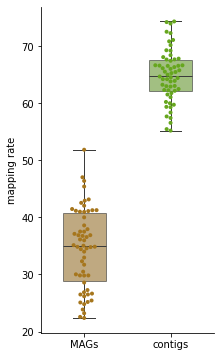

In [4]:
df_lr = df[df['type']=='sr']
target_order = ['MAGs', 'contigs']
custom_palette = {
    'MAGs': '#a6761d',
    'contigs': '#66a61e',
}
fig, ax = plt.subplots(figsize=(4,6))
ax=sns.boxplot(data=df_lr, width=.5,x="target", y="mapping rate",color='white',order=target_order,palette=custom_palette,boxprops=dict(alpha=0.6) )
sns.swarmplot(data=df_lr, x="target",s=4,y="mapping rate",order=target_order,palette=custom_palette)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.subplots_adjust(left=0.3) 
ax.set_xlabel('')
plt.savefig('D:\soil\manuscript\draft\mine\mapping_sr.svg')

<ipython-input-10-eb9b257aff7f>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=df_lr, width=.5,x="target", y="mapping rate",color='white',order=target_order,palette=custom_palette,boxprops=dict(alpha=0.6) )
<ipython-input-10-eb9b257aff7f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df_lr, x="target",s=4,y="mapping rate",order=target_order,palette=custom_palette)


Text(0.5, 33.0, '')

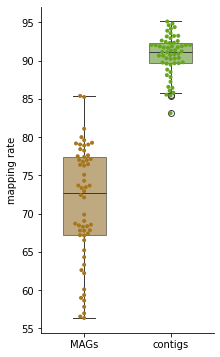

In [10]:
df_lr = df[df['type']=='lr']
target_order = ['MAGs', 'contigs']
custom_palette = {
    'MAGs': '#a6761d',
    'contigs': '#66a61e',
}
fig, ax = plt.subplots(figsize=(4,6))
ax=sns.boxplot(data=df_lr, width=.5,x="target", y="mapping rate",color='white',order=target_order,palette=custom_palette,boxprops=dict(alpha=0.6) )
sns.swarmplot(data=df_lr, x="target",s=4,y="mapping rate",order=target_order,palette=custom_palette)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.subplots_adjust(left=0.3) 
ax.set_xlabel('')

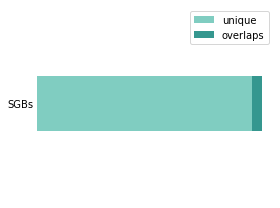

In [11]:
df = pd.read_csv(r'../pre-calculated_data/overlap_all.csv', index_col=0)

fig, ax = plt.subplots(figsize=(4, 3))

df.plot.barh(
    stacked=True,
    color=['#80cdc1','#35978f'],
    width=0.2,
    ax=ax 
)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.set_xticklabels([])
plt.tight_layout()  

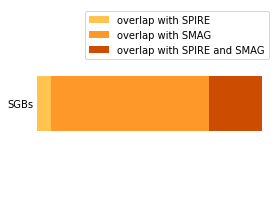

In [13]:
df = pd.read_csv(r'../pre-calculated_data/overlap.csv', index_col=0)

fig, ax = plt.subplots(figsize=(4, 3))

df.plot.barh(
    stacked=True,
    color=['#fec44f', '#fe9929', '#cc4c02'],
    width=0.2,
    ax=ax 
)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.set_xticklabels([])

plt.tight_layout()